In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import IPython.display as ipd

In [4]:
comex = pd.read_csv('comex_gold_comm_60.csv')
equity = pd.read_csv('gold_etf_equity_60.csv')

In [5]:
comex["Time"] = pd.to_datetime(comex["Time"])
equity["Time"] = pd.to_datetime(equity["Time"])

comex = comex.sort_values(["Time", "symbol"]).reset_index(drop=True)
equity = equity.sort_values(["Time", "symbol"]).reset_index(drop=True)

In [6]:
comex["root"] = np.where(
    comex["symbol"].str.startswith("MGC"),
    "MGC",
    "GC"
)

In [7]:
comex.head()

,Time,symbol,vwap,vwap_traded_volume,uptick_volume,downtick_volume,trade_size_at_ask,trade_size_at_bid,root
0,2026-07-08 00:01:00,GC\Q26,4134.811494,87,30,21,40,26,GC
1,2026-07-08 00:01:00,GC\Z26,4195.950000,2,2,0,1,0,GC
2,2026-07-08 00:01:00,MGC\Q26,4134.915000,220,55,49,89,93,MGC
3,2026-07-08 00:02:00,GC\Q26,4134.100000,57,13,10,37,14,GC
4,2026-07-08 00:02:00,GC\U26,4147.900000,1,1,0,0,1,GC


In [8]:
equity.head()

,Time,symbol,vwap,vwap_traded_volume,uptick_volume,downtick_volume,trade_size_at_ask,trade_size_at_bid
0,2026-07-08 04:01:00,GLD,378.131062,2463,1146,1092,15,403
1,2026-07-08 04:01:00,IAU,77.596770,547,507,39,4,2
2,2026-07-08 04:02:00,GLD,378.395302,1422,637,496,17,159
3,2026-07-08 04:02:00,IAU,77.490930,86,29,37,0,11
4,2026-07-08 04:03:00,GLD,377.805570,527,1,308,0,0


In [9]:
comex.isna().sum()

Time                  0
symbol                0
vwap                  0
vwap_traded_volume    0
uptick_volume         0
downtick_volume       0
trade_size_at_ask     0
trade_size_at_bid     0
root                  0
dtype: int64

In [10]:
equity.isna().sum()

Time                    0
symbol                  0
vwap                  148
vwap_traded_volume      0
uptick_volume           0
downtick_volume         0
trade_size_at_ask       0
trade_size_at_bid       0
dtype: int64

`last_trade` not needed since `vwap` is present for all rows

In [11]:
# converting to notional for comex data
comex['notional_usd'] = (
    comex['vwap_traded_volume']
    * comex['vwap']
    * np.where(comex['symbol'].str.startswith('MGC'), 10, 100)
)

# converting to notional for equity data
equity['notional_usd'] = (
    equity['vwap_traded_volume']
    *equity['vwap']
)

In [12]:
comex['date'] = comex['Time'].dt.date
comex = comex[['Time', 'date', 'symbol', 'root', 'notional_usd', 'vwap', 'vwap_traded_volume', 'uptick_volume', 'downtick_volume', 'trade_size_at_ask', 'trade_size_at_bid']]

equity['date'] = equity['Time'].dt.date
equity = equity[['Time', 'date', 'symbol', 'notional_usd', 'vwap', 'vwap_traded_volume', 'uptick_volume', 'downtick_volume', 'trade_size_at_ask', 'trade_size_at_bid']]

In [13]:
# ── Step 1: Daily vol sum per (date, root, symbol) ─────────────────────────
daily_vol_by_symbol = (
    comex
    .groupby(['date', 'root', 'symbol'], as_index=False)['vwap_traded_volume']
    .sum()
    .rename(columns={'vwap_traded_volume': 'daily_vol'})
)

# ── Step 2: Pick the dominant symbol per (date, root) ──────────────────────
comex_highest_vol = (
    daily_vol_by_symbol
    .loc[daily_vol_by_symbol.groupby(['date', 'root'])['daily_vol'].idxmax()]
    .reset_index(drop=True)
)

In [14]:
comex_highest_vol.head()

,date,root,symbol,daily_vol
0,2026-07-08,GC,GC\Q26,152211
1,2026-07-08,MGC,MGC\Q26,331844
2,2026-07-09,GC,GC\Q26,100798
3,2026-07-09,MGC,MGC\Q26,237759
4,2026-07-10,GC,GC\Q26,71830


now we filter down to the final comex data containing only the highest traded volume symbol for each date

In [16]:
# ── Step 3: Semi-join — merge on all 3 keys so no extra cols are added ──────
# Only rows where (date, root, symbol) exists in dominant_symbol_map survive
comex_front_expiry = (
    comex
    .merge(comex_highest_vol[['date', 'root', 'symbol']], on=['date', 'root', 'symbol'], how='inner')
    .reset_index(drop=True)
)

In [89]:
comex_front_expiry.head()

,Time,date,symbol,root,notional_usd,vwap,vwap_traded_volume,uptick_volume,downtick_volume,trade_size_at_ask,trade_size_at_bid,minute_num
0,2026-07-08 00:01:00,2026-07-08,GC\Q26,GC,35972860.0,4134.811494,87,30,21,40,26,1
1,2026-07-08 00:01:00,2026-07-08,MGC\Q26,MGC,9096813.0,4134.915000,220,55,49,89,93,1
2,2026-07-08 00:02:00,2026-07-08,GC\Q26,GC,23564370.0,4134.100000,57,13,10,37,14,2
3,2026-07-08 00:02:00,2026-07-08,MGC\Q26,MGC,6862437.0,4133.998193,166,27,39,47,86,2
4,2026-07-08 00:03:00,2026-07-08,GC\Q26,GC,11985870.0,4133.058621,29,7,13,6,15,3


- now for the all expiry data, we aggregate down to the additive quantities across all symbols of each root at each minute
- eg.: how many gc and mgc traded at 1000 hrs on 8th july
- totally different from `comex_front_expiry`

In [18]:
comex_all_expiry = (
    comex
    .groupby(['Time', 'date', 'root'], as_index=False)
    .agg(
        notional_usd=('notional_usd', 'sum'),
        vwap_traded_volume=('vwap_traded_volume', 'sum'),
        uptick_volume=('uptick_volume', 'sum'),
        downtick_volume=('downtick_volume', 'sum'),
        trade_size_at_ask=('trade_size_at_ask', 'sum'),
        trade_size_at_bid=('trade_size_at_bid', 'sum')
    )
)

In [19]:
comex_all_expiry.head()

,Time,date,root,notional_usd,vwap_traded_volume,uptick_volume,downtick_volume,trade_size_at_ask,trade_size_at_bid
0,2026-07-08 00:01:00,2026-07-08,GC,36812050.0,89,32,21,41,26
1,2026-07-08 00:01:00,2026-07-08,MGC,9096813.0,220,55,49,89,93
2,2026-07-08 00:02:00,2026-07-08,GC,23979160.0,58,14,10,37,15
3,2026-07-08 00:02:00,2026-07-08,MGC,6904062.0,167,28,39,47,87
4,2026-07-08 00:03:00,2026-07-08,GC,11985870.0,29,7,13,6,15


## Exercise 1

In [20]:
# Date
comex_front_expiry['date'] = comex_front_expiry['Time'].dt.date
equity['date'] = equity['Time'].dt.date

# Minute of day: 00:00 -> 0, 09:30 -> 570, 13:30 -> 810, etc.
comex_front_expiry['minute_num'] = (
    comex_front_expiry['Time'].dt.hour * 60
    + comex_front_expiry['Time'].dt.minute
)

equity['minute_num'] = (
    equity['Time'].dt.hour * 60
    + equity['Time'].dt.minute
)

In [21]:
# One row per exact minute, columns = GC and MGC
comex_minute = (
    comex_front_expiry
    .groupby(['Time', 'date', 'minute_num', 'root'], as_index=False)['notional_usd']
    .sum()
)

comex_plot = (
    comex_minute
    .pivot_table(
        index=['Time', 'date', 'minute_num'],
        columns='root',
        values='notional_usd',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

comex_plot['GC+MGC'] = comex_plot['GC'] + comex_plot['MGC']

In [22]:
equity_minute = (
    equity
    .groupby(['Time', 'date', 'minute_num', 'symbol'], as_index=False)['notional_usd']
    .sum()
)

equity_plot = (
    equity_minute
    .pivot_table(
        index=['Time', 'date', 'minute_num'],
        columns='symbol',
        values='notional_usd',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

equity_plot['GLD+IAU'] = equity_plot['GLD'] + equity_plot['IAU']

In [23]:
session_markers = {
    'London open': 3 * 60,           # 03:00 ET
    'NYSE open': 9 * 60 + 30,        # 09:30 ET
    'COMEX close': 13 * 60 + 30,     # 13:30 ET
    'NYSE close': 16 * 60            # 16:00 ET
}

In [24]:
def format_minute_axis(ax):
    ticks = np.arange(0, 24 * 60 + 1, 60)  # hourly

    labels = [
        f'{m // 60:02d}:{m % 60:02d}'
        for m in ticks
    ]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_xlabel('Time of day (ET)')

In [25]:
def format_equity_axis(ax):
    """Same as format_minute_axis but clipped to NYSE hours (04:00–20:00)."""
    format_minute_axis(ax)
    ax.set_xlim(4 * 60, 20 * 60)   # 240 → 1200 minutes

In [26]:
def add_session_markers(ax):
    for label, minute in session_markers.items():
        ax.axvline(
            minute,
            linestyle='--',
            alpha=0.7,
            linewidth=1
        )

        ax.text(
            minute,
            0.98,
            label,
            rotation=90,
            va='top',
            ha='right',
            transform=ax.get_xaxis_transform()
        )

### 1a (3 single days)

In [27]:
selected_dates = [
    pd.to_datetime('2026-07-14').date(),
    pd.to_datetime('2026-07-29').date(),
    pd.to_datetime('2026-08-12').date()
]

for comex

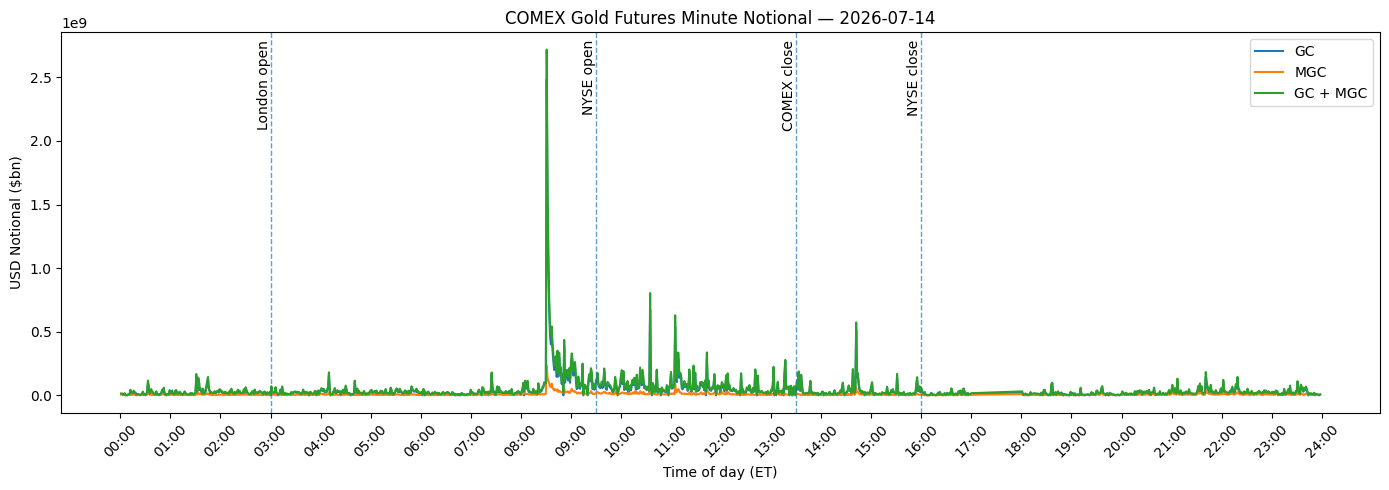

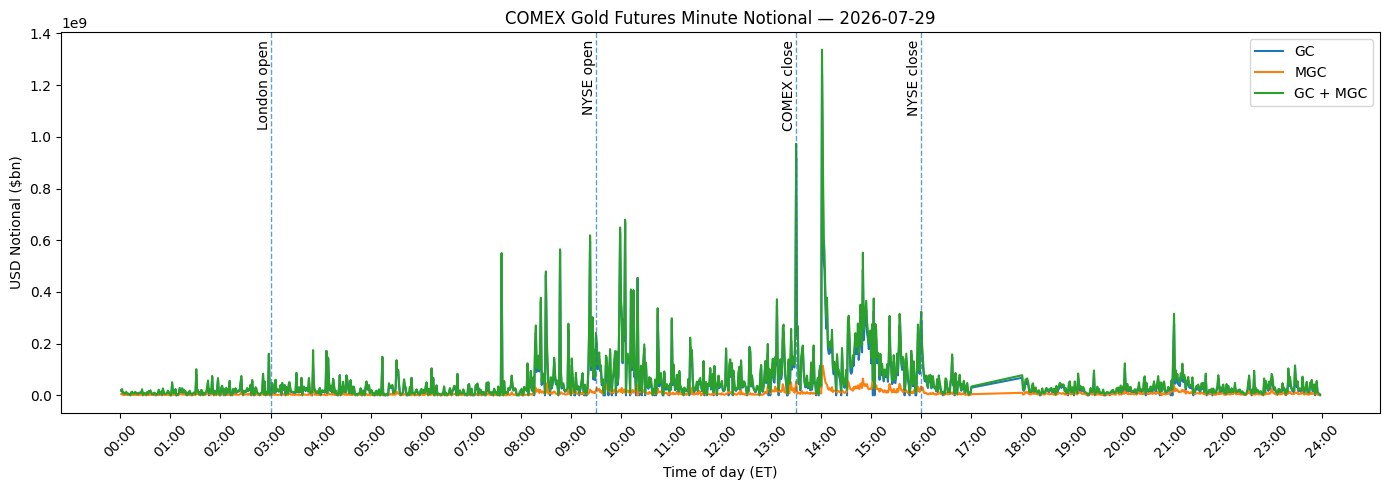

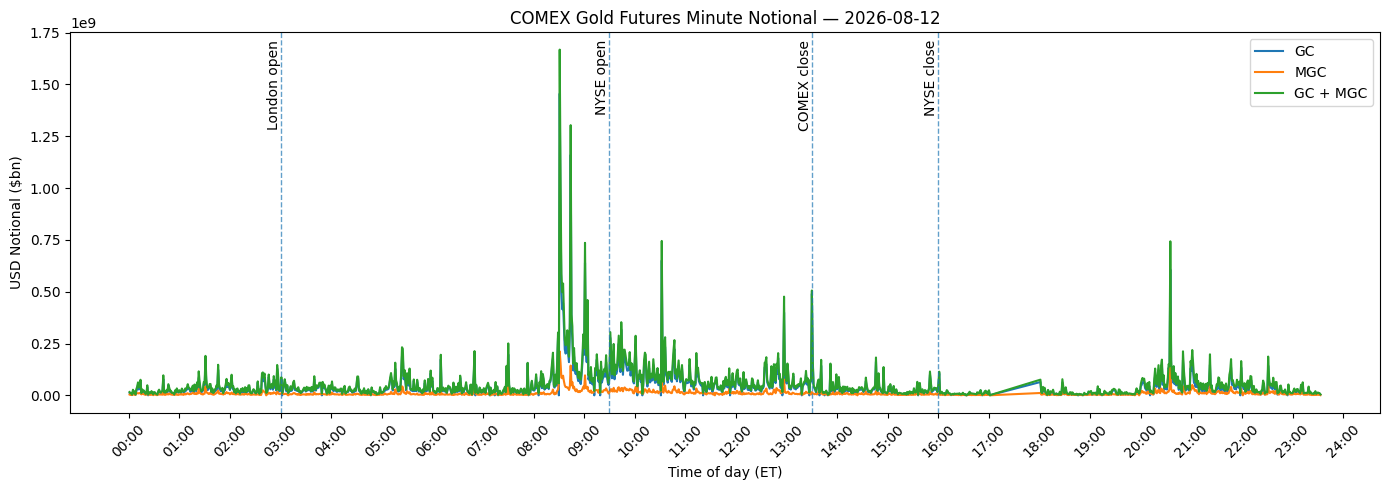

In [28]:
for selected_date in selected_dates:

    day = (
        comex_plot[
            comex_plot['date'] == selected_date
        ]
        .sort_values('minute_num')
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        day['minute_num'],
        day['GC'],
        label='GC'
    )

    plt.plot(
        day['minute_num'],
        day['MGC'],
        label='MGC'
    )

    plt.plot(
        day['minute_num'],
        day['GC+MGC'],
        label='GC + MGC'
    )

    ax = plt.gca()

    add_session_markers(ax)
    format_minute_axis(ax)

    plt.title(
        f'COMEX Gold Futures Minute Notional — {selected_date}'
    )

    plt.ylabel('USD Notional ($bn)')
    plt.legend()
    plt.tight_layout()
    plt.show()

for equity

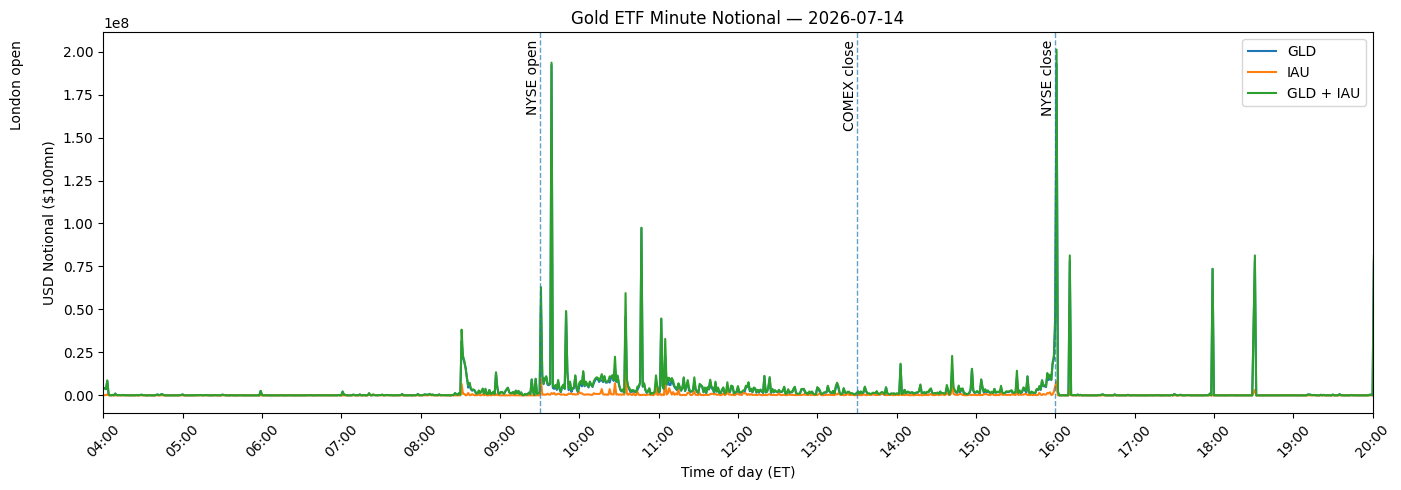

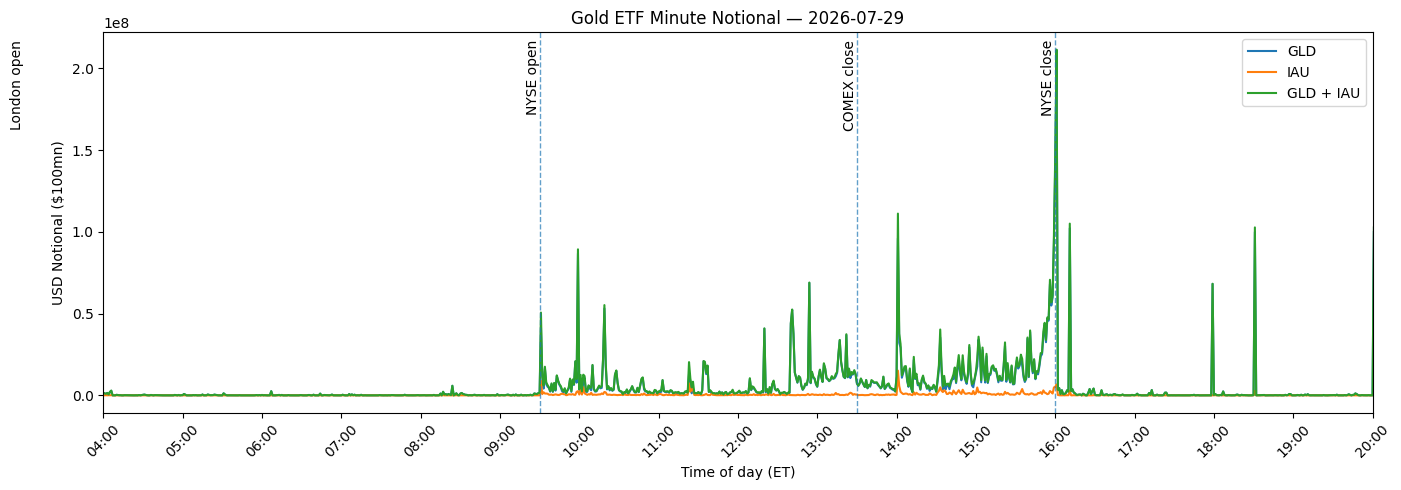

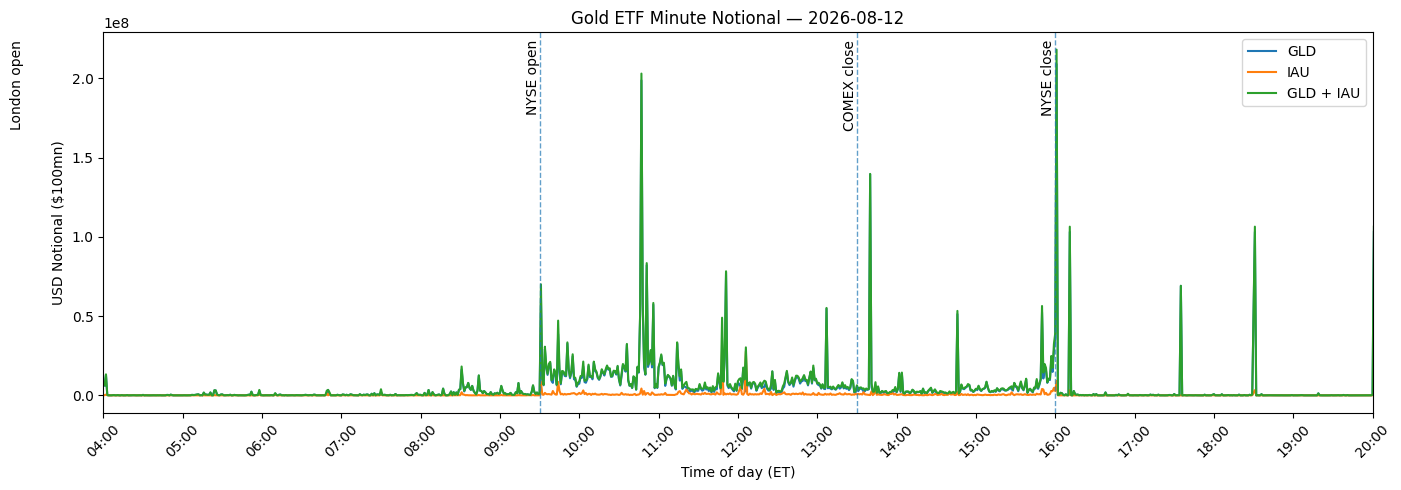

In [29]:
for selected_date in selected_dates:

    day = (
        equity_plot[
            equity_plot['date'] == selected_date
        ]
        .sort_values('minute_num')
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        day['minute_num'],
        day['GLD'],
        label='GLD'
    )

    plt.plot(
        day['minute_num'],
        day['IAU'],
        label='IAU'
    )

    plt.plot(
        day['minute_num'],
        day['GLD+IAU'],
        label='GLD + IAU'
    )

    ax = plt.gca()

    add_session_markers(ax)
    format_equity_axis(ax)

    plt.title(
        f'Gold ETF Minute Notional — {selected_date}'
    )

    plt.ylabel('USD Notional ($100mn)')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 1b (cross day)

for comex

In [30]:
comex_profile = (
    comex_plot
    .groupby('minute_num')
    .agg(
        GC_median=('GC', 'median'),
        GC_p25=('GC', lambda x: x.quantile(0.25)),
        GC_p75=('GC', lambda x: x.quantile(0.75)),

        MGC_median=('MGC', 'median'),
        MGC_p25=('MGC', lambda x: x.quantile(0.25)),
        MGC_p75=('MGC', lambda x: x.quantile(0.75)),

        TOTAL_median=('GC+MGC', 'median'),
        TOTAL_p25=('GC+MGC', lambda x: x.quantile(0.25)),
        TOTAL_p75=('GC+MGC', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

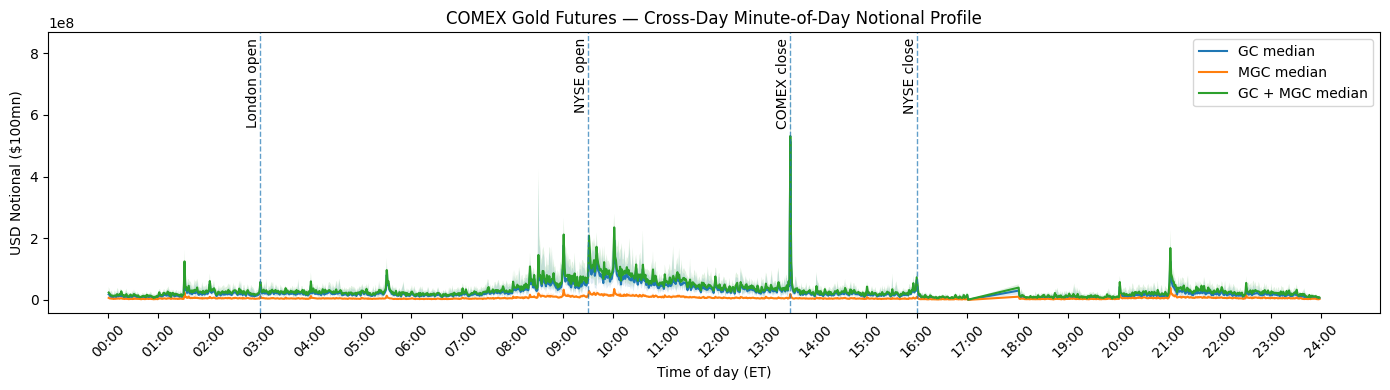

In [31]:
plt.figure(figsize=(14, 4))

# GC
plt.plot(
    comex_profile['minute_num'],
    comex_profile['GC_median'],
    label='GC median'
)

plt.fill_between(
    comex_profile['minute_num'],
    comex_profile['GC_p25'],
    comex_profile['GC_p75'],
    alpha=0.15
)

# MGC
plt.plot(
    comex_profile['minute_num'],
    comex_profile['MGC_median'],
    label='MGC median'
)

plt.fill_between(
    comex_profile['minute_num'],
    comex_profile['MGC_p25'],
    comex_profile['MGC_p75'],
    alpha=0.15
)

# Combined
plt.plot(
    comex_profile['minute_num'],
    comex_profile['TOTAL_median'],
    label='GC + MGC median'
)

plt.fill_between(
    comex_profile['minute_num'],
    comex_profile['TOTAL_p25'],
    comex_profile['TOTAL_p75'],
    alpha=0.15
)

ax = plt.gca()

add_session_markers(ax)
format_minute_axis(ax)

plt.title(
    'COMEX Gold Futures — Cross-Day Minute-of-Day Notional Profile'
)

plt.ylabel('USD Notional ($100mn)')
plt.legend()
plt.tight_layout()
plt.show()

for equity

In [32]:
equity_profile = (
    equity_plot
    .groupby('minute_num')
    .agg(
        GLD_median=('GLD', 'median'),
        GLD_p25=('GLD', lambda x: x.quantile(0.25)),
        GLD_p75=('GLD', lambda x: x.quantile(0.75)),

        IAU_median=('IAU', 'median'),
        IAU_p25=('IAU', lambda x: x.quantile(0.25)),
        IAU_p75=('IAU', lambda x: x.quantile(0.75)),

        TOTAL_median=('GLD+IAU', 'median'),
        TOTAL_p25=('GLD+IAU', lambda x: x.quantile(0.25)),
        TOTAL_p75=('GLD+IAU', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

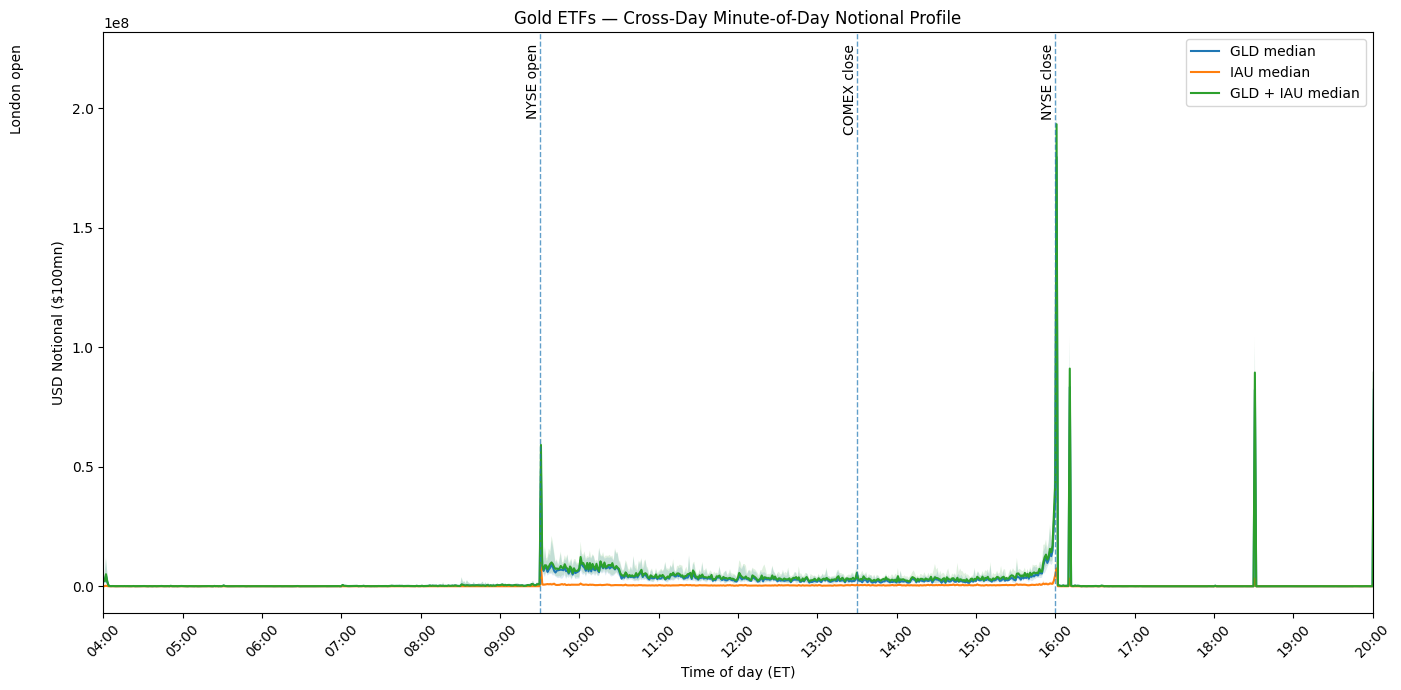

In [33]:
plt.figure(figsize=(14, 7))

# GLD
plt.plot(
    equity_profile['minute_num'],
    equity_profile['GLD_median'],
    label='GLD median'
)

plt.fill_between(
    equity_profile['minute_num'],
    equity_profile['GLD_p25'],
    equity_profile['GLD_p75'],
    alpha=0.15
)

# IAU
plt.plot(
    equity_profile['minute_num'],
    equity_profile['IAU_median'],
    label='IAU median'
)

plt.fill_between(
    equity_profile['minute_num'],
    equity_profile['IAU_p25'],
    equity_profile['IAU_p75'],
    alpha=0.15
)

# Combined
plt.plot(
    equity_profile['minute_num'],
    equity_profile['TOTAL_median'],
    label='GLD + IAU median'
)

plt.fill_between(
    equity_profile['minute_num'],
    equity_profile['TOTAL_p25'],
    equity_profile['TOTAL_p75'],
    alpha=0.15
)

ax = plt.gca()

add_session_markers(ax)
format_equity_axis(ax)

plt.title(
    'Gold ETFs — Cross-Day Minute-of-Day Notional Profile'
)

plt.ylabel('USD Notional ($100mn)')
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 2

In [34]:
# Separate dataframe for aggressive-volume analysis
comex_aggressive = comex_front_expiry.copy()

# Aggressive volumes (tick rule)
comex_aggressive['agg_buy_volume'] = comex_aggressive['uptick_volume']
comex_aggressive['agg_sell_volume'] = comex_aggressive['downtick_volume']

# Signed aggression volume
comex_aggressive['signed_agg_volume'] = (
    comex_aggressive['agg_buy_volume']
    - comex_aggressive['agg_sell_volume']
)

# Contract multiplier
comex_aggressive['multiplier'] = np.where(
    comex_aggressive['root'] == 'GC',
    100,
    10
)

# Aggressive USD notionals
comex_aggressive['agg_buy_notional'] = (
    comex_aggressive['agg_buy_volume']
    * comex_aggressive['vwap']
    * comex_aggressive['multiplier']
)

comex_aggressive['agg_sell_notional'] = (
    comex_aggressive['agg_sell_volume']
    * comex_aggressive['vwap']
    * comex_aggressive['multiplier']
)

# Net signed aggressive notional
comex_aggressive['signed_agg_notional'] = (
    comex_aggressive['agg_buy_notional']
    - comex_aggressive['agg_sell_notional']
)

# organizing
comex_aggressive = comex_aggressive[[
    'Time', 'date', 'symbol', 'root', 'notional_usd', 'vwap', 'vwap_traded_volume',
    'agg_buy_volume', 'agg_buy_notional',
    'agg_sell_volume', 'agg_sell_notional',
    'signed_agg_volume', 'signed_agg_notional',
    'trade_size_at_ask', 'trade_size_at_bid', 'minute_num'
]]

In [35]:
comex_aggressive.head()

,Time,date,symbol,root,notional_usd,vwap,vwap_traded_volume,agg_buy_volume,agg_buy_notional,agg_sell_volume,agg_sell_notional,signed_agg_volume,signed_agg_notional,trade_size_at_ask,trade_size_at_bid,minute_num
0,2026-07-08 00:01:00,2026-07-08,GC\Q26,GC,35972860.0,4134.811494,87,30,1.240443e+07,21,8.683104e+06,9,3.721330e+06,40,26,1
1,2026-07-08 00:01:00,2026-07-08,MGC\Q26,MGC,9096813.0,4134.915000,220,55,2.274203e+06,49,2.026108e+06,6,2.480949e+05,89,93,1
2,2026-07-08 00:02:00,2026-07-08,GC\Q26,GC,23564370.0,4134.100000,57,13,5.374330e+06,10,4.134100e+06,3,1.240230e+06,37,14,2
3,2026-07-08 00:02:00,2026-07-08,MGC\Q26,MGC,6862437.0,4133.998193,166,27,1.116180e+06,39,1.612259e+06,-12,-4.960798e+05,47,86,2
4,2026-07-08 00:03:00,2026-07-08,GC\Q26,GC,11985870.0,4133.058621,29,7,2.893141e+06,13,5.372976e+06,-6,-2.479835e+06,6,15,3


In [36]:
# now rolling up to daily totals
comex_daily_aggressive = (
    comex_aggressive
    .groupby(['date', 'root'], as_index=False)
    .agg(
        agg_buy_notional=('agg_buy_notional', 'sum'),
        agg_sell_notional=('agg_sell_notional', 'sum'),
        signed_agg_notional=('signed_agg_notional', 'sum')
    )
)

In [37]:
comex_daily_aggressive.head()

,date,root,agg_buy_notional,agg_sell_notional,signed_agg_notional
0,2026-07-08,GC,1.625994e+10,2.088740e+10,-4.627464e+09
1,2026-07-08,MGC,3.379349e+09,3.409504e+09,-3.015555e+07
2,2026-07-09,GC,1.025599e+10,1.495005e+10,-4.694055e+09
3,2026-07-09,MGC,2.314948e+09,2.303508e+09,1.144022e+07
4,2026-07-10,GC,7.545818e+09,1.024790e+10,-2.702080e+09


In [38]:
# Separate dataframe for aggressive-volume analysis
equity_aggressive = equity.copy()

# Aggressive volumes (tick rule)
equity_aggressive['agg_buy_volume'] = equity_aggressive['uptick_volume']
equity_aggressive['agg_sell_volume'] = equity_aggressive['downtick_volume']

# Signed aggression
equity_aggressive['signed_agg_volume'] = (
    equity_aggressive['agg_buy_volume']
    - equity_aggressive['agg_sell_volume']
)

# Aggressive USD notionals
equity_aggressive['agg_buy_notional'] = (
    equity_aggressive['agg_buy_volume']
    * equity_aggressive['vwap']
)

equity_aggressive['agg_sell_notional'] = (
    equity_aggressive['agg_sell_volume']
    * equity_aggressive['vwap']
)

# Net signed aggressive notional
equity_aggressive['signed_agg_notional'] = (
    equity_aggressive['agg_buy_notional']
    - equity_aggressive['agg_sell_notional']
)

# organizing
equity_aggressive = equity_aggressive[[
    'Time', 'date', 'symbol', 'notional_usd', 'vwap', 'vwap_traded_volume',
    'agg_buy_volume', 'agg_buy_notional',
    'agg_sell_volume', 'agg_sell_notional',
    'signed_agg_volume', 'signed_agg_notional',
    'trade_size_at_ask', 'trade_size_at_bid', 'minute_num'
]]

In [39]:
equity_aggressive.head()

,Time,date,symbol,notional_usd,vwap,vwap_traded_volume,agg_buy_volume,agg_buy_notional,agg_sell_volume,agg_sell_notional,signed_agg_volume,signed_agg_notional,trade_size_at_ask,trade_size_at_bid,minute_num
0,2026-07-08 04:01:00,2026-07-08,GLD,931336.8056,378.131062,2463,1146,433338.197003,1092,412919.119657,54,20419.077346,15,403,241
1,2026-07-08 04:01:00,2026-07-08,IAU,42445.4332,77.596770,547,507,39341.562399,39,3026.274031,468,36315.288369,4,2,241
2,2026-07-08 04:02:00,2026-07-08,GLD,538078.1200,378.395302,1422,637,241037.807623,496,187684.069986,141,53353.737637,17,159,242
3,2026-07-08 04:02:00,2026-07-08,IAU,6664.2200,77.490930,86,29,2247.236977,37,2867.164419,-8,-619.927442,0,11,242
4,2026-07-08 04:03:00,2026-07-08,GLD,199103.5355,377.805570,527,1,377.805570,308,116364.115624,-307,-115986.310054,0,0,243


In [40]:
# now rolling up to daily totals
equity_daily_aggressive = (
    equity_aggressive
    .groupby(['date', 'symbol'], as_index=False)
    .agg(
        agg_buy_notional=('agg_buy_notional', 'sum'),
        agg_sell_notional=('agg_sell_notional', 'sum'),
        signed_agg_notional=('signed_agg_notional', 'sum')
    )
)

In [41]:
equity_daily_aggressive.head()

,date,symbol,agg_buy_notional,agg_sell_notional,signed_agg_notional
0,2026-07-08,GLD,8.070680e+08,7.169913e+08,9.007671e+07
1,2026-07-08,IAU,5.240949e+07,5.979557e+07,-7.386084e+06
2,2026-07-09,GLD,6.045382e+08,5.921414e+08,1.239680e+07
3,2026-07-09,IAU,1.471888e+08,8.013223e+07,6.705656e+07
4,2026-07-10,GLD,6.685490e+08,5.284198e+08,1.401292e+08


now plotting panelwise for comex and equity

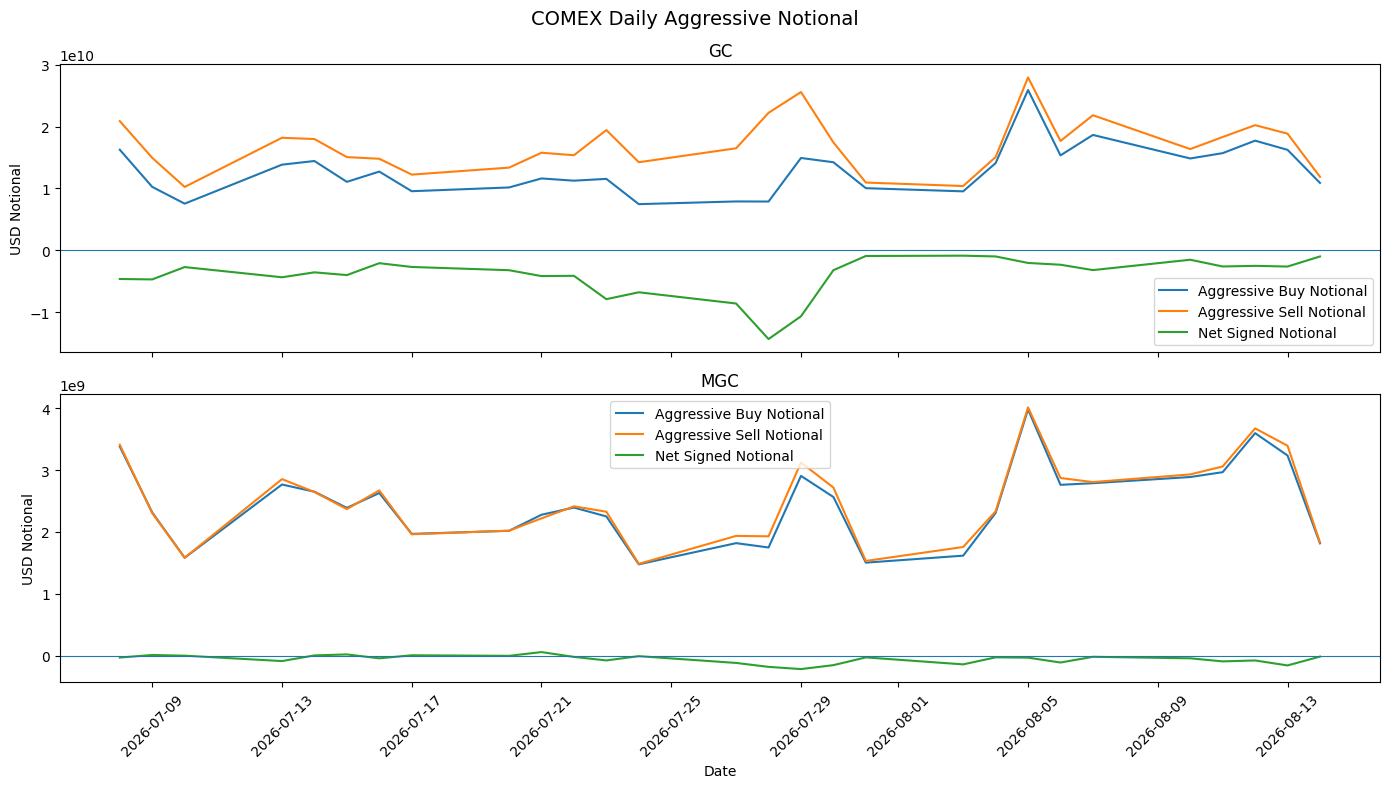

In [42]:
# COMEX: GC and MGC

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True
)

for ax, root in zip(axes, ['GC', 'MGC']):

    temp = (
        comex_daily_aggressive[
            comex_daily_aggressive['root'] == root
        ]
        .sort_values('date')
    )

    ax.plot(
        temp['date'],
        temp['agg_buy_notional'],
        label='Aggressive Buy Notional'
    )

    ax.plot(
        temp['date'],
        temp['agg_sell_notional'],
        label='Aggressive Sell Notional'
    )

    ax.plot(
        temp['date'],
        temp['signed_agg_notional'],
        label='Net Signed Notional'
    )

    ax.axhline(0, linewidth=0.8)
    ax.set_title(root)
    ax.set_ylabel('USD Notional')
    ax.legend()

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d')
)

plt.xticks(rotation=45)

fig.suptitle(
    'COMEX Daily Aggressive Notional',
    fontsize=14
)

plt.tight_layout()
plt.show()

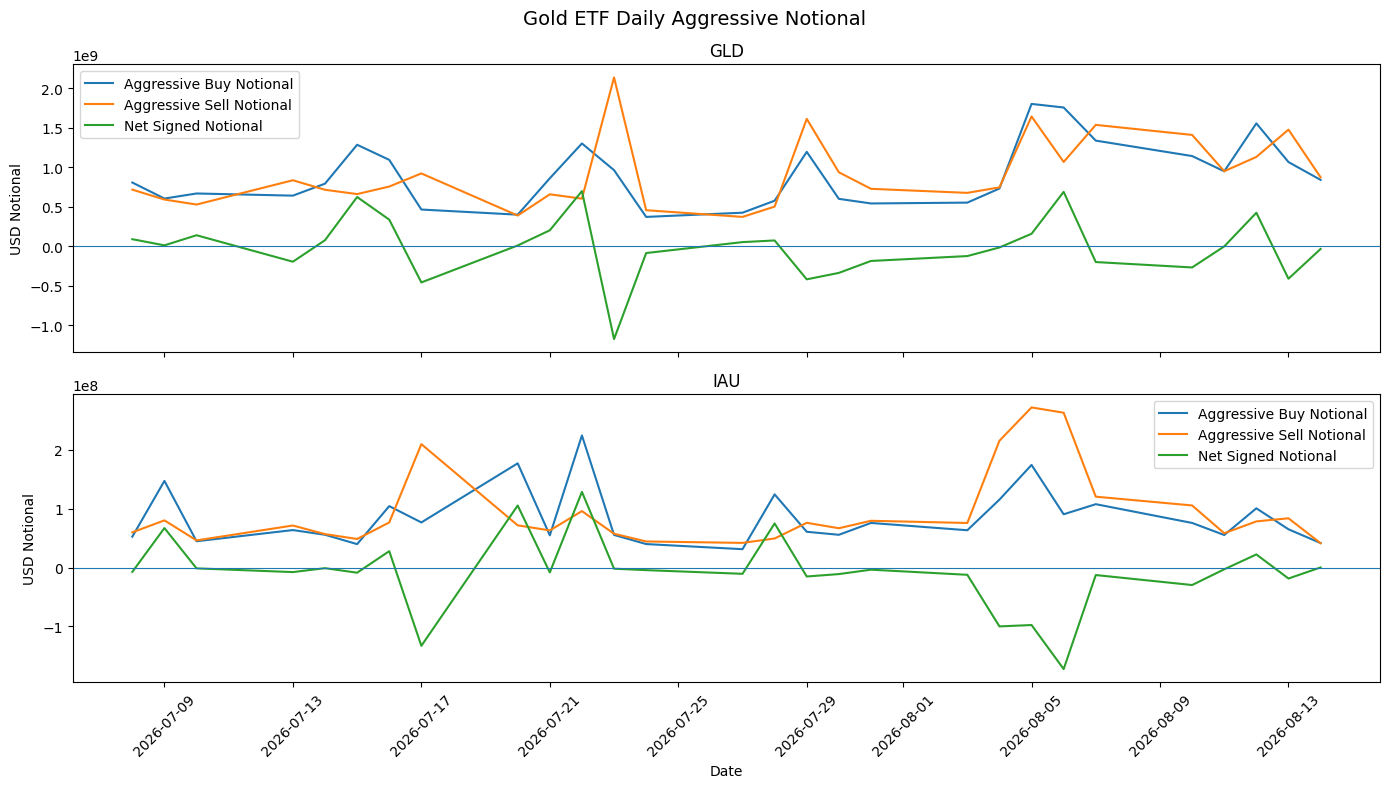

In [43]:
# ETFs: GLD and IAU

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True
)

for ax, symbol in zip(axes, ['GLD', 'IAU']):

    temp = (
        equity_daily_aggressive[
            equity_daily_aggressive['symbol'] == symbol
        ]
        .sort_values('date')
    )

    ax.plot(
        temp['date'],
        temp['agg_buy_notional'],
        label='Aggressive Buy Notional'
    )

    ax.plot(
        temp['date'],
        temp['agg_sell_notional'],
        label='Aggressive Sell Notional'
    )

    ax.plot(
        temp['date'],
        temp['signed_agg_notional'],
        label='Net Signed Notional'
    )

    ax.axhline(0, linewidth=0.8)
    ax.set_title(symbol)
    ax.set_ylabel('USD Notional')
    ax.legend()

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d')
)

plt.xticks(rotation=45)

fig.suptitle(
    'Gold ETF Daily Aggressive Notional',
    fontsize=14
)

plt.tight_layout()
plt.show()

minute wise net print comparison for comex and equity for 2 random days

In [44]:
# COMEX: combine GC + MGC at each minute
comex_minute_aggressive = (
    comex_aggressive
    .groupby(['date', 'Time'], as_index=False)
    .agg(
        agg_buy_notional=('agg_buy_notional', 'sum'),
        agg_sell_notional=('agg_sell_notional', 'sum'),
        signed_agg_notional=('signed_agg_notional', 'sum')
    )
)

# ETF: combine GLD + IAU at each minute
equity_minute_aggressive = (
    equity_aggressive
    .groupby(['date', 'Time'], as_index=False)
    .agg(
        agg_buy_notional=('agg_buy_notional', 'sum'),
        agg_sell_notional=('agg_sell_notional', 'sum'),
        signed_agg_notional=('signed_agg_notional', 'sum')
    )
)

2 biggest comex net prints

In [45]:
# Top 2 largest COMEX minute-level net prints
top2_comex_prints = (
    comex_minute_aggressive
    .assign(
        abs_signed_agg=lambda x: x['signed_agg_notional'].abs()
    )
    .nlargest(2, 'abs_signed_agg')
    .reset_index(drop=True)
)

top2_comex_prints

,date,Time,agg_buy_notional,agg_sell_notional,signed_agg_notional,abs_signed_agg
0,2026-07-28,2026-07-28 13:30:00,1.180116e+08,1.298007e+09,-1.179995e+09,1.179995e+09
1,2026-07-20,2026-07-20 13:30:00,8.003721e+07,7.939468e+08,-7.139096e+08,7.139096e+08


finding the equity net prints for the same 2 timestamps as comex

In [46]:
top2_comex_with_equity = (
    top2_comex_prints[
        ['date', 'Time', 'signed_agg_notional']
    ]
    .rename(
        columns={
            'signed_agg_notional': 'comex_signed_agg_notional'
        }
    )
    .merge(
        equity_minute_aggressive[
            ['Time', 'signed_agg_notional']
        ].rename(
            columns={
                'signed_agg_notional': 'equity_signed_agg_notional'
            }
        ),
        on='Time',
        how='left'
    )
)

top2_comex_with_equity

,date,Time,comex_signed_agg_notional,equity_signed_agg_notional
0,2026-07-28,2026-07-28 13:30:00,-1.179995e+09,-157256.048731
1,2026-07-20,2026-07-20 13:30:00,-7.139096e+08,198019.932818


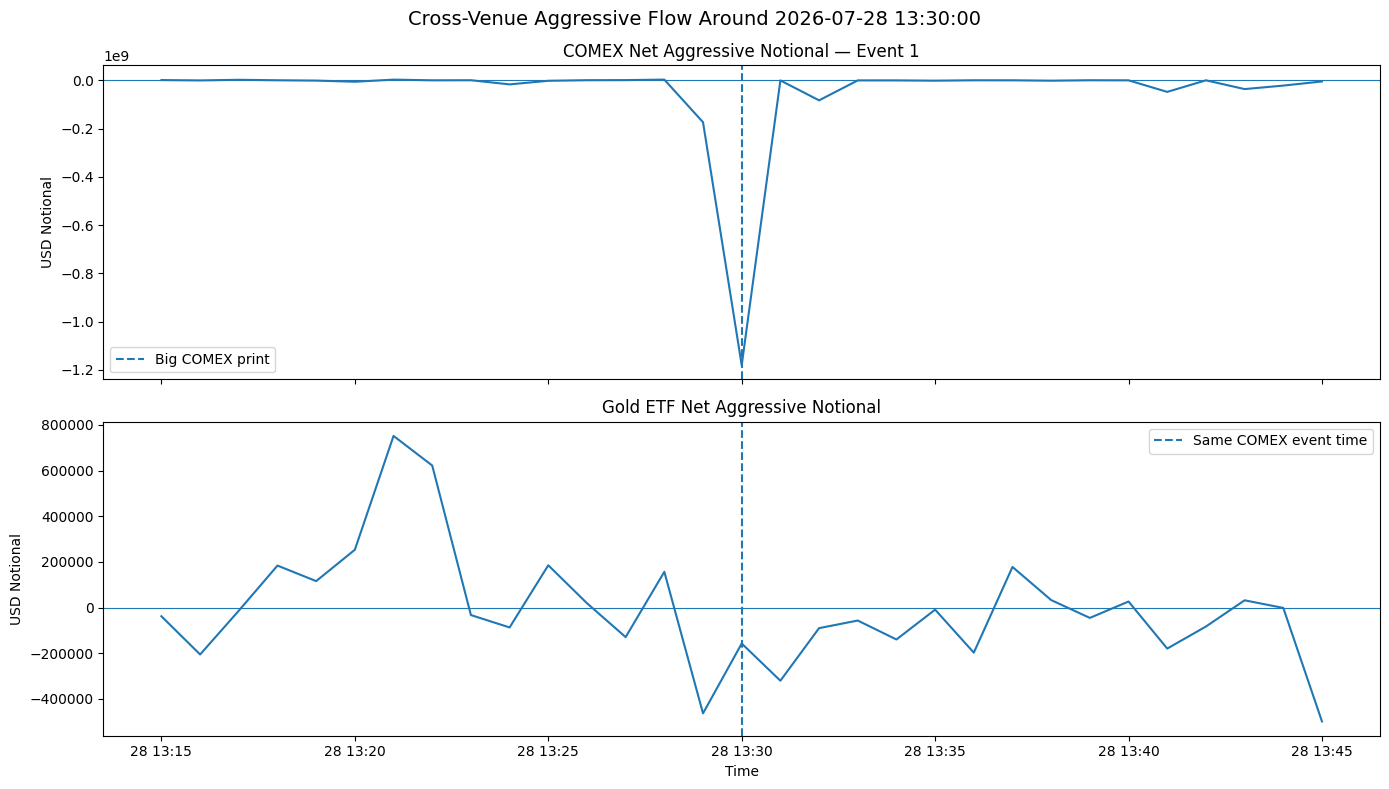

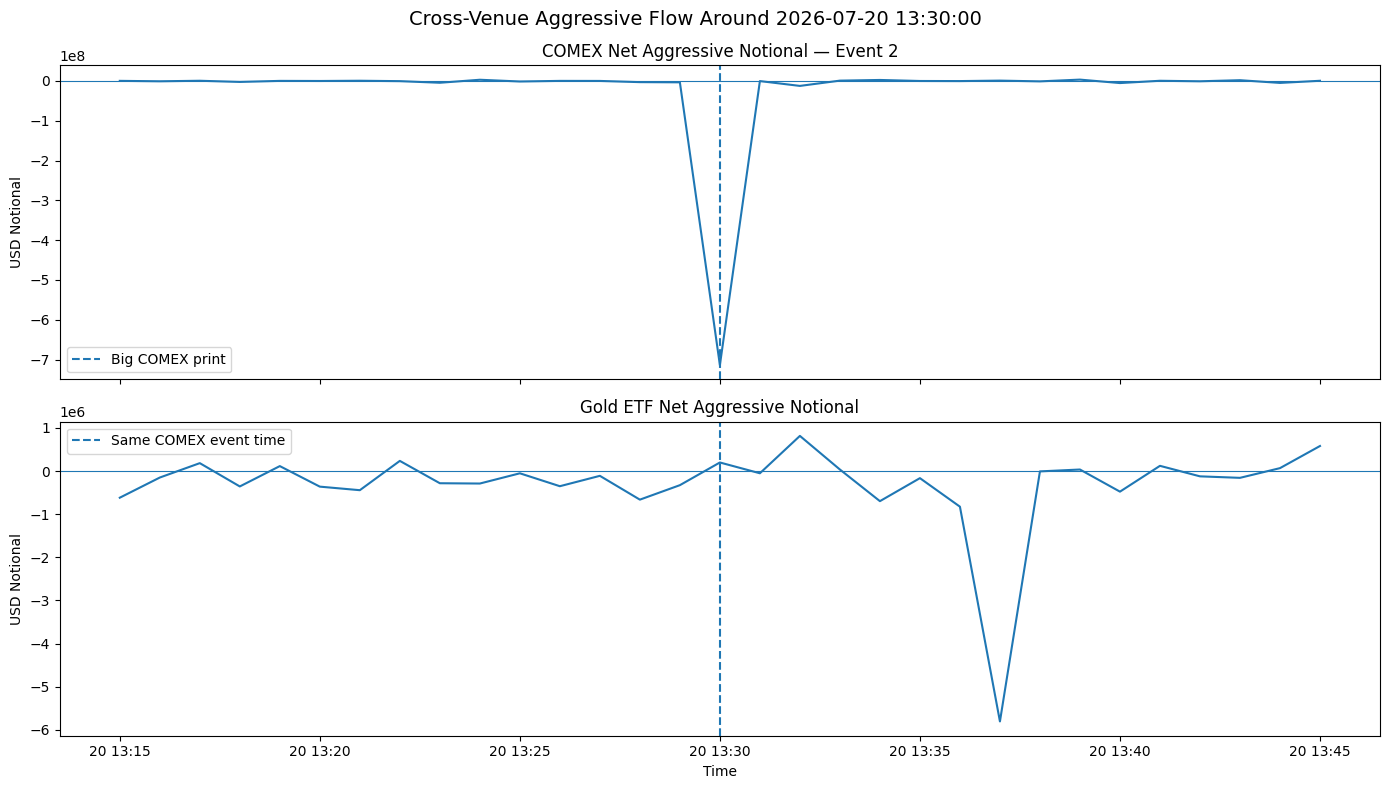

In [47]:
for i, event in top2_comex_prints.iterrows():

    event_time = event['Time']

    window_start = event_time - pd.Timedelta(minutes=15)
    window_end   = event_time + pd.Timedelta(minutes=15)

    comex_window = comex_minute_aggressive[
        (comex_minute_aggressive['Time'] >= window_start) &
        (comex_minute_aggressive['Time'] <= window_end)
    ].copy()

    equity_window = equity_minute_aggressive[
        (equity_minute_aggressive['Time'] >= window_start) &
        (equity_minute_aggressive['Time'] <= window_end)
    ].copy()

    fig, axes = plt.subplots(
        2, 1,
        figsize=(14, 8),
        sharex=True
    )

    # COMEX
    axes[0].plot(
        comex_window['Time'],
        comex_window['signed_agg_notional']
    )

    axes[0].axhline(0, linewidth=0.8)

    axes[0].axvline(
        event_time,
        linestyle='--',
        label='Big COMEX print'
    )

    axes[0].set_title(
        f'COMEX Net Aggressive Notional — Event {i + 1}'
    )

    axes[0].set_ylabel('USD Notional')
    axes[0].legend()

    # Equity
    axes[1].plot(
        equity_window['Time'],
        equity_window['signed_agg_notional']
    )

    axes[1].axhline(0, linewidth=0.8)

    axes[1].axvline(
        event_time,
        linestyle='--',
        label='Same COMEX event time'
    )

    axes[1].set_title(
        'Gold ETF Net Aggressive Notional'
    )

    axes[1].set_ylabel('USD Notional')
    axes[1].set_xlabel('Time')
    axes[1].legend()

    fig.suptitle(
        f'Cross-Venue Aggressive Flow Around {event_time}',
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

it can be observed that comex got the largest net prints on the closing time of 1330 hrs, which is the `comex metal close`, both *sell-sided*

*Q: Is a busy gold day busy in both venues?*

In [48]:
# combine GC+MGC into comex daily activity
comex_daily_activity = (
    comex_daily_aggressive
    .groupby('date', as_index=False)
    .agg(
        agg_buy_notional=('agg_buy_notional', 'sum'),
        agg_sell_notional=('agg_sell_notional', 'sum')
    )
)

comex_daily_activity['total_aggressive_notional'] = (
    comex_daily_activity['agg_buy_notional']
    + comex_daily_activity['agg_sell_notional']
)

In [49]:
# combine GLD+IAU into equity daily activity
equity_daily_activity = (
    equity_daily_aggressive
    .groupby('date', as_index=False)
    .agg(
        agg_buy_notional=('agg_buy_notional', 'sum'),
        agg_sell_notional=('agg_sell_notional', 'sum')
    )
)

equity_daily_activity['total_aggressive_notional'] = (
    equity_daily_activity['agg_buy_notional']
    + equity_daily_activity['agg_sell_notional']
)

In [50]:
# now merging the two
daily_activity_comparison = pd.merge(
    comex_daily_activity[
        ['date', 'total_aggressive_notional']
    ].rename(
        columns={
            'total_aggressive_notional': 'comex_activity'
        }
    ),

    equity_daily_activity[
        ['date', 'total_aggressive_notional']
    ].rename(
        columns={
            'total_aggressive_notional': 'equity_activity'
        }
    ),

    on='date',
    how='inner'
)

In [51]:
daily_activity_comparison.head()

,date,comex_activity,equity_activity
0,2026-07-08,4.393620e+10,1.636264e+09
1,2026-07-09,2.982450e+10,1.424001e+09
2,2026-07-10,2.095887e+10,1.287730e+09
3,2026-07-13,3.766318e+10,1.612254e+09
4,2026-07-14,3.772316e+10,1.620543e+09


In [52]:
activity_corr = (
    daily_activity_comparison[
        ['comex_activity', 'equity_activity']
    ]
    .corr()
    .iloc[0, 1]
)

print('COMEX vs EQUITY daily activity correlation:', round(activity_corr, 2))

COMEX vs EQUITY daily activity correlation: 0.77


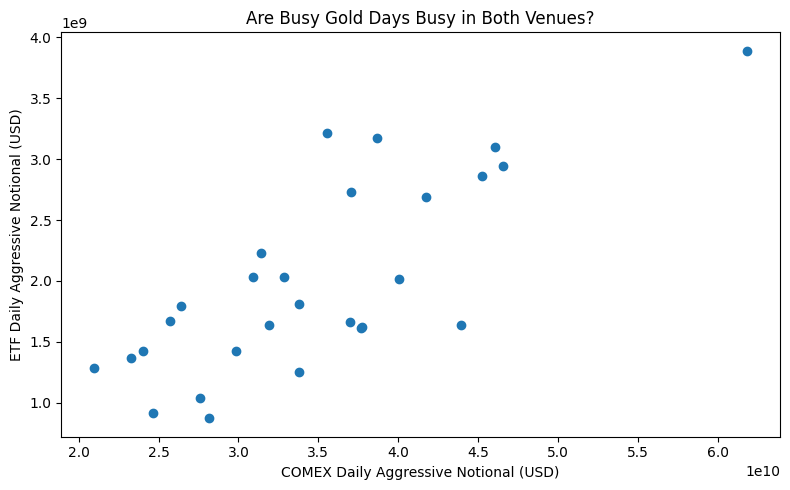

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_activity_comparison['comex_activity'],
    daily_activity_comparison['equity_activity']
)

plt.xlabel('COMEX Daily Aggressive Notional (USD)')
plt.ylabel('ETF Daily Aggressive Notional (USD)')
plt.title('Are Busy Gold Days Busy in Both Venues?')

plt.tight_layout()
plt.show()

From the scatter plot, we can see that the answer is more or less, yes

*Q: Does GC net aggressive flow line up with GLD on the same day, or diverge?*

In [54]:
# filtering out GC and GLD by date and merging
gc_daily = (
    comex_daily_aggressive[
        comex_daily_aggressive['root'] == 'GC'
    ][['date', 'signed_agg_notional']]
    .rename(
        columns={
            'signed_agg_notional': 'gc_net_aggression'
        }
    )
)

gld_daily = (
    equity_daily_aggressive[
        equity_daily_aggressive['symbol'] == 'GLD'
    ][['date', 'signed_agg_notional']]
    .rename(
        columns={
            'signed_agg_notional': 'gld_net_aggression'
        }
    )
)

gc_gld_daily = pd.merge(
    gc_daily,
    gld_daily,
    on='date',
    how='inner'
).sort_values('date')

gc_gld_daily.head()

,date,gc_net_aggression,gld_net_aggression
0,2026-07-08,-4.627464e+09,9.007671e+07
1,2026-07-09,-4.694055e+09,1.239680e+07
2,2026-07-10,-2.702080e+09,1.401292e+08
3,2026-07-13,-4.347905e+09,-1.946882e+08
4,2026-07-14,-3.551664e+09,7.750997e+07


In [55]:
# testing same day alignment
same_day_corr = (
    gc_gld_daily['gc_net_aggression']
    .corr(gc_gld_daily['gld_net_aggression'])
)

print('Same-day GC vs GLD correlation:', round(same_day_corr, 2))

Same-day GC vs GLD correlation: 0.19


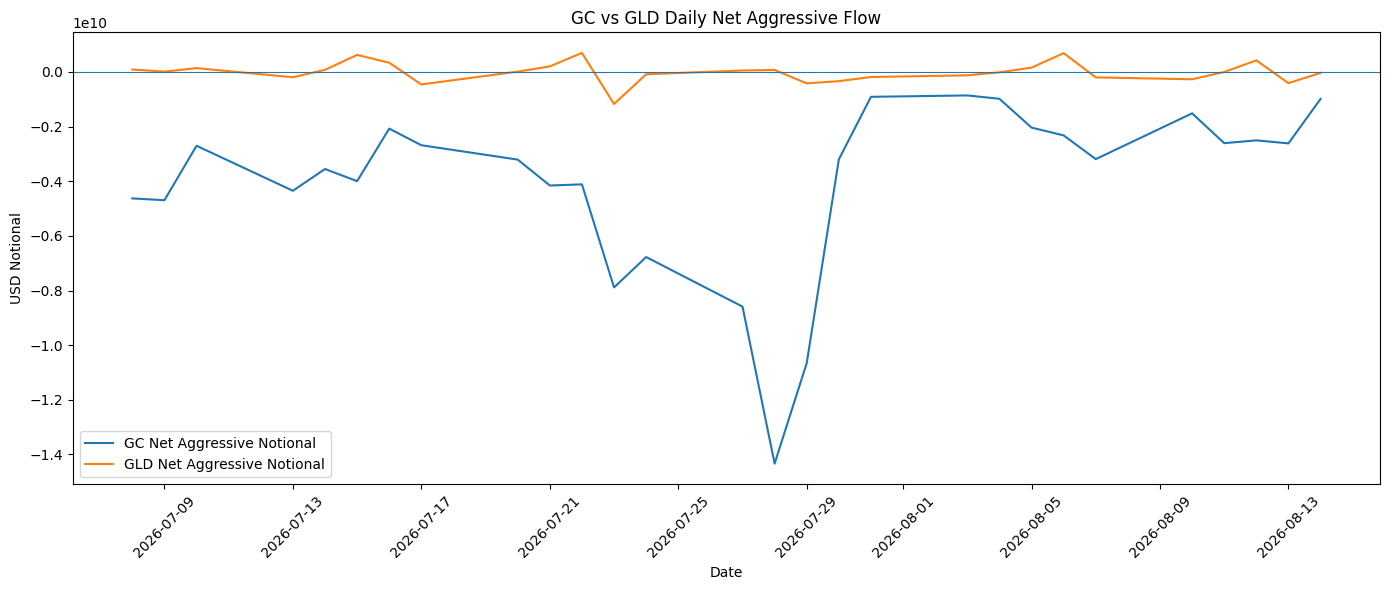

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    gc_gld_daily['date'],
    gc_gld_daily['gc_net_aggression'],
    label='GC Net Aggressive Notional'
)

plt.plot(
    gc_gld_daily['date'],
    gc_gld_daily['gld_net_aggression'],
    label='GLD Net Aggressive Notional'
)

plt.axhline(0, linewidth=0.8)

plt.xlabel('Date')
plt.ylabel('USD Notional')
plt.title('GC vs GLD Daily Net Aggressive Flow')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

with a 19% positive correlation we can say that GC and GLD have a same day lineup, although its very weak, hence inconclusive, as seen from the signs of net aggressive flow from the graph above

## Follow-on questions

### 2 - Front Month Roll

*Q: Plot daily volume and open-interest share (if available) of the two nearest GC expiries through a roll. When does liquidity switch?*

This is a continuation of Q1 from the exercises, where we just have to add the `second highest` expiry symbol for GC, since the first/highest is already present as `front expiry`

using `daily_vol_ranked` data as it contains all the daily volumes, grouped by date, root and symbol

In [82]:
# now getting the second highest expiry symbol
# Rank each symbol by daily volume within each date/root
daily_vol_ranked = (
    daily_vol_by_symbol
    .sort_values(
        ['date', 'root', 'daily_vol'],
        ascending=[True, True, False]
    )
    .copy()
)

daily_vol_ranked['volume_rank'] = (
    daily_vol_ranked
    .groupby(['date', 'root'])
    .cumcount() + 1
)

In [93]:
# gc_first_expiry: same structure as gc_second_expiry, using daily_vol_ranked with rank == 1, GC only
gc_first_expiry = (
    daily_vol_ranked[
        (daily_vol_ranked['volume_rank'] == 1) &
        (daily_vol_ranked['root'] == 'GC')
    ]
    .reset_index(drop=True)
)

gc_first_expiry.head()

,date,root,symbol,daily_vol,volume_rank
0,2026-07-08,GC,GC\Q26,152211,1
1,2026-07-09,GC,GC\Q26,100798,1
2,2026-07-10,GC,GC\Q26,71830,1
3,2026-07-13,GC,GC\Q26,132826,1
4,2026-07-14,GC,GC\Q26,132575,1


In [84]:
# Keep the second-highest-volume expiry
comex_second_highest_vol = (
    daily_vol_ranked[
        daily_vol_ranked['volume_rank'] == 2
    ]
    .reset_index(drop=True)
)

# filtering for GC symbol only
gc_second_expiry = (
    comex_second_highest_vol[
        comex_second_highest_vol['root'] == 'GC'
    ]
    .reset_index(drop=True)
)

gc_second_expiry.head()

,date,root,symbol,daily_vol,volume_rank
0,2026-07-08,GC,GC\Z26,9210,2
1,2026-07-09,GC,GC\Z26,5057,2
2,2026-07-10,GC,GC\Z26,5389,2
3,2026-07-13,GC,GC\Z26,11446,2
4,2026-07-14,GC,GC\Z26,9397,2


In [95]:
# inspect which symbols the first/second expiries are producing
gc_top2 = (
    daily_vol_ranked[
        (daily_vol_ranked['root'] == 'GC') &
        (daily_vol_ranked['volume_rank'].isin([1, 2]))
    ]
    .sort_values(['date', 'volume_rank'])
    .reset_index(drop=True)
)

gc_top2[['date', 'symbol', 'daily_vol', 'volume_rank']].head(10)

,date,symbol,daily_vol,volume_rank
0,2026-07-08,GC\Q26,152211,1
1,2026-07-08,GC\Z26,9210,2
2,2026-07-09,GC\Q26,100798,1
3,2026-07-09,GC\Z26,5057,2
4,2026-07-10,GC\Q26,71830,1
5,2026-07-10,GC\Z26,5389,2
6,2026-07-13,GC\Q26,132826,1
7,2026-07-13,GC\Z26,11446,2
8,2026-07-14,GC\Q26,132575,1
9,2026-07-14,GC\Z26,9397,2


now trying to find a roll/liquidity switch in contracts

In [ ]:
# ── Already have gc_first_expiry (rank1) and gc_second_expiry (rank2), so merging them ──────
gc_roll_pivot = (
    gc_first_expiry[['date', 'symbol']].rename(columns={'symbol': 'rank1'})
    .merge(
        gc_second_expiry[['date', 'symbol']].rename(columns={'symbol': 'rank2'}),
        on='date',
        how='outer'
    )
    .sort_values('date')
    .reset_index(drop=True)
)

gc_roll_pivot.head(10)

,date,rank1,rank2
0,2026-07-08,GC\Q26,GC\Z26
1,2026-07-09,GC\Q26,GC\Z26
2,2026-07-10,GC\Q26,GC\Z26
3,2026-07-13,GC\Q26,GC\Z26
4,2026-07-14,GC\Q26,GC\Z26
5,2026-07-15,GC\Q26,GC\Z26
6,2026-07-16,GC\Q26,GC\Z26
7,2026-07-17,GC\Q26,GC\Z26
8,2026-07-20,GC\Q26,GC\Z26
9,2026-07-21,GC\Q26,GC\Z26


- now looking for rows where the rank 1 symbol switched places with the rank 2 symbol in the next row, and flagging them
- if flagged true, its assigned as a `clean_roll`

In [103]:
# ── Carry forward yesterday's values ───────────────────────────────────────
gc_roll_pivot['prev_rank1'] = gc_roll_pivot['rank1'].shift(1)
gc_roll_pivot['prev_rank2'] = gc_roll_pivot['rank2'].shift(1)

# ── Flag dates where rank1 changed ─────────────────────────────────────────
gc_roll_pivot['rank1_changed'] = (
    gc_roll_pivot['rank1'] != gc_roll_pivot['prev_rank1']
)

# ── Flag clean adjacent roll (new rank1 was yesterday's rank2) ─────────────
gc_roll_pivot['clean_roll'] = (
    gc_roll_pivot['rank1_changed'] &
    (gc_roll_pivot['rank1'] == gc_roll_pivot['prev_rank2'])
)

gc_roll_pivot.head(10)

,date,rank1,rank2,prev_rank1,prev_rank2,rank1_changed,clean_roll
0,2026-07-08,GC\Q26,GC\Z26,None,None,True,False
1,2026-07-09,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
2,2026-07-10,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
3,2026-07-13,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
4,2026-07-14,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
5,2026-07-15,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
6,2026-07-16,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
7,2026-07-17,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
8,2026-07-20,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False
9,2026-07-21,GC\Q26,GC\Z26,GC\Q26,GC\Z26,False,False


In [101]:
# ── All switch events ───────────────────────────────────────────────────────
roll_events = gc_roll_pivot[
    gc_roll_pivot['rank1_changed'] & gc_roll_pivot['prev_rank1'].notna()
][['date', 'prev_rank1', 'prev_rank2', 'rank1', 'rank2', 'clean_roll']]

print(roll_events)

first_roll = roll_events.iloc[0]
print(f"\nFirst roll on: {first_roll['date']}")
print(f"  {first_roll['prev_rank1']} → {first_roll['rank1']}  (clean adjacent: {first_roll['clean_roll']})")

          date prev_rank1 prev_rank2   rank1   rank2  clean_roll
15  2026-07-29     GC\Q26     GC\Z26  GC\Z26  GC\Q26        True

First roll on: 2026-07-29
  GC\Q26 → GC\Z26  (clean adjacent: True)


*Hence, the answer is: liquidity switched on `29th July 2026`, for the said window*

### 5 - Spreads

*Q: `avg_spread` by minute for GLD vs a GC bid/ask proxy. When is the ETF expensive relative to futures?*

In [58]:
# load the required data
gc_spread = pd.read_csv('gc_spread_data_5.csv')
gld_spread = pd.read_csv('gld_spread_data_5.csv')

# sort time
gc_spread['Time'] = pd.to_datetime(gc_spread['Time'])
gld_spread['Time'] = pd.to_datetime(gld_spread['Time'])

gc_spread = gc_spread.sort_values('Time').reset_index(drop=True)
gld_spread = gld_spread.sort_values('Time').reset_index(drop=True)

In [59]:
# computing midpoint and proxy spread in basis points for gc
gc_spread['mid_price'] = (
    gc_spread['last_ask'] + gc_spread['last_bid']
) / 2

gc_spread['spread_proxy'] = (
    gc_spread['last_ask'] - gc_spread['last_bid']
)

gc_spread['proxy_spread_bps'] = (
    gc_spread['spread_proxy']
    / gc_spread['mid_price']
    * 10000
)

In [60]:
gld_spread['mid_price'] = (
    gld_spread['last_ask'] + gld_spread['last_bid']
) / 2

gld_spread['spread_bps'] = (
    gld_spread['avg_spread']
    / gld_spread['mid_price']
) * 10000

In [61]:
# creating minute of day
gc_spread['minute_num'] = (
    gc_spread['Time'].dt.hour * 60
    + gc_spread['Time'].dt.minute
)

gld_spread['minute_num'] = (
    gld_spread['Time'].dt.hour * 60
    + gld_spread['Time'].dt.minute
)

In [62]:
# use the median spread at each minute of day
gc_proxy_spread_profile = (
    gc_spread
    .groupby('minute_num', as_index=False)
    .agg(
        gc_proxy_spread_bps=('proxy_spread_bps', 'median')
    )
)

gld_spread_profile = (
    gld_spread
    .groupby('minute_num', as_index=False)
    .agg(
        gld_spread_bps=('spread_bps', 'median')
    )
)

In [63]:
# comparing only the minutes where both gc proxy and gld exist
spread_comparison = pd.merge(
    gc_proxy_spread_profile,
    gld_spread_profile,
    on='minute_num',
    how='inner'
)

spread_comparison['spread_gap_bps'] = (
    spread_comparison['gld_spread_bps']
    - spread_comparison['gc_proxy_spread_bps']
)

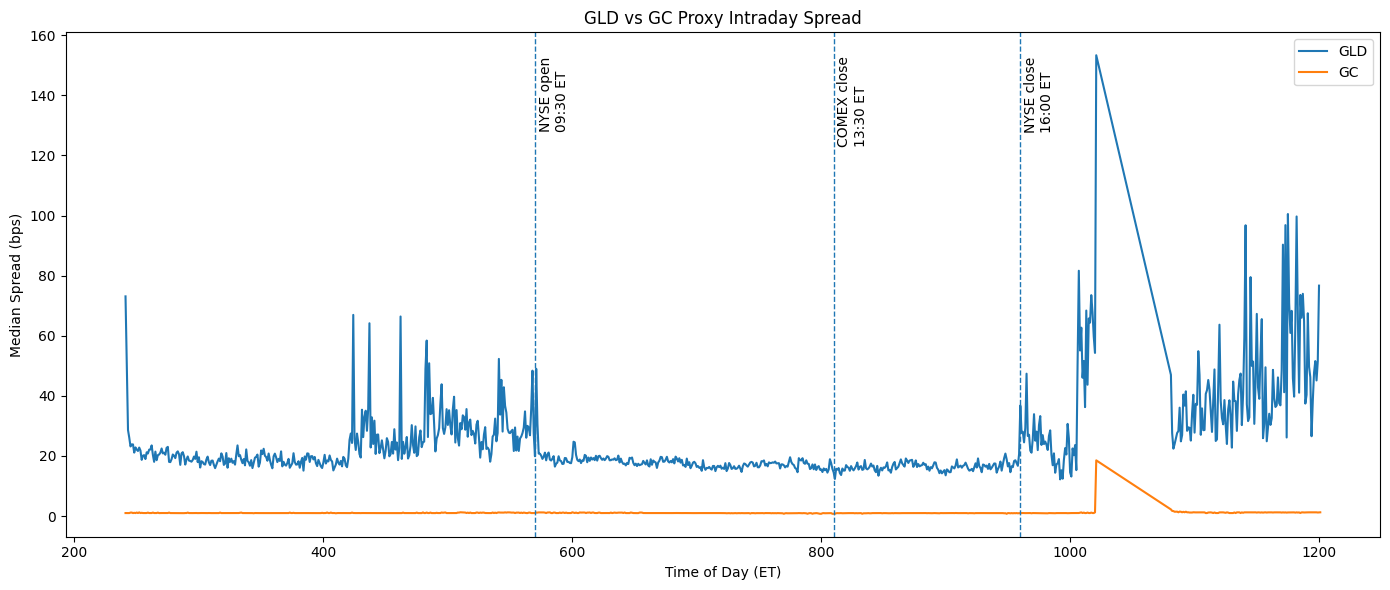

In [64]:
plt.figure(figsize=(14, 6))

plt.plot(
    spread_comparison['minute_num'],
    spread_comparison['gld_spread_bps'],
    label='GLD'
)

plt.plot(
    spread_comparison['minute_num'],
    spread_comparison['gc_proxy_spread_bps'],
    label='GC'
)

# Session markers
session_lines = {
    'NYSE open\n09:30 ET': 9 * 60 + 30,
    'COMEX close\n13:30 ET': 13 * 60 + 30,
    'NYSE close\n16:00 ET': 16 * 60
}

for label, x in session_lines.items():
    plt.axvline(
        x,
        linestyle='--',
        linewidth=1
    )

    plt.text(
        x + 3,
        plt.ylim()[1] * 0.95,
        label,
        rotation=90,
        va='top',
        ha='left'
    )

plt.xlabel('Time of Day (ET)')
plt.ylabel('Median Spread (bps)')
plt.title('GLD vs GC Proxy Intraday Spread')

# Legend now only needs GLD and GC
plt.legend()

plt.tight_layout()
plt.show()

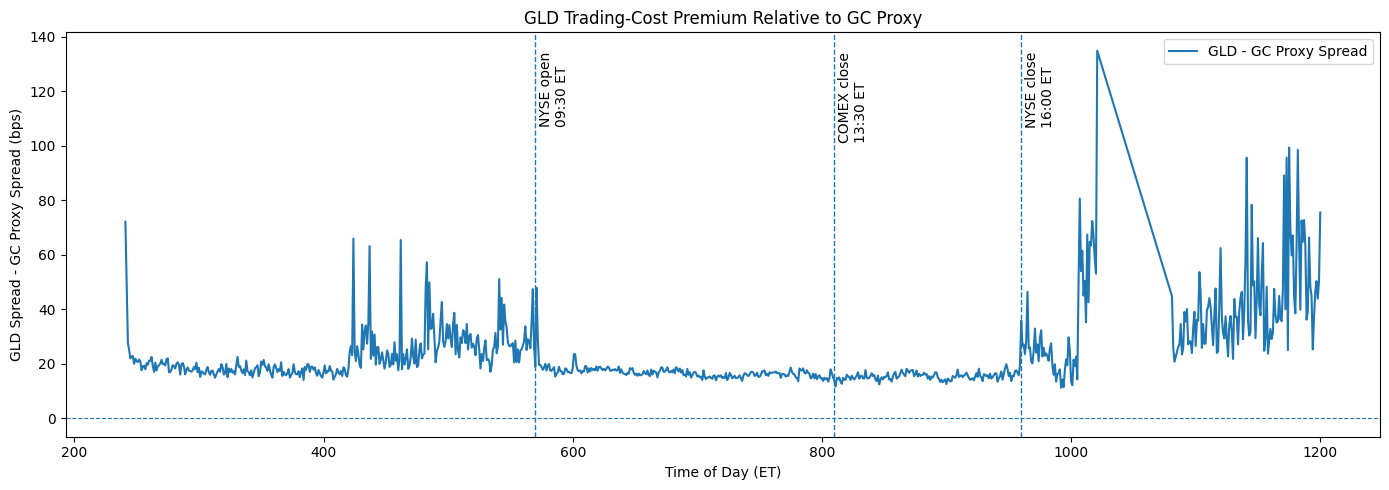

In [65]:
plt.figure(figsize=(14, 5))

plt.plot(
    spread_comparison['minute_num'],
    spread_comparison['spread_gap_bps'],
    label='GLD - GC Proxy Spread'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=0.8
)

for label, x in session_lines.items():
    plt.axvline(
        x,
        linestyle='--',
        linewidth=1
    )

    plt.text(
        x + 3,
        plt.ylim()[1] * 0.95,
        label,
        rotation=90,
        va='top',
        ha='left'
    )

plt.xlabel('Time of Day (ET)')
plt.ylabel('GLD Spread - GC Proxy Spread (bps)')
plt.title('GLD Trading-Cost Premium Relative to GC Proxy')

plt.legend()
plt.tight_layout()
plt.show()

- since the line is always above zero, etf is always more expensive than futures
- GLD is more expensive than GC throughout the overlapping period on a spread-bps basis, but the relative cost is lowest and relatively stable during regular trading hours. The ETF becomes substantially more expensive around and especially after the 16:00 ET NYSE close, when GLD spreads widen sharply while GC spreads remain comparatively tight.

In [66]:
print("GLD")
print(
    gld_spread[
        ['last_bid', 'last_ask', 'avg_spread']
    ].describe()
)

print("\nGC")
print(
    gc_spread[
        ['last_bid', 'last_ask', 'avg_spread']
    ].describe()
)

GLD
           last_bid      last_ask    avg_spread
count  25138.000000  25135.000000  25576.000000
mean     358.396444    361.722012      1.520746
std       87.817216     84.619909      3.779034
min        0.000000      0.000000      0.000000
25%      370.000000    370.710000      0.540187
50%      373.700000    374.280000      0.723359
75%      388.970000    390.080000      1.053800
max      407.020000    592.600000    151.503750

GC
           last_bid      last_ask    avg_spread
count  69774.000000  69774.000000  69774.000000
mean    4170.219352   4170.662290      0.455108
std      141.240567    141.219071      0.120884
min     3965.400000   3965.900000      0.198387
25%     4068.225000   4068.700000      0.382628
50%     4113.700000   4114.200000      0.442827
75%     4287.900000   4288.300000      0.508775
max     4516.600000   4518.100000      3.382864


In [67]:
gld_spread['last_quote_spread'] = (
    gld_spread['last_ask']
    - gld_spread['last_bid']
)

gc_spread['last_quote_spread'] = (
    gc_spread['last_ask']
    - gc_spread['last_bid']
)

In [68]:
print(
    gld_spread[
        ['avg_spread', 'last_quote_spread']
    ].describe()
)

print('\n',
    gc_spread[
        ['avg_spread', 'last_quote_spread']
    ].describe()
)

         avg_spread  last_quote_spread
count  25576.000000       25007.000000
mean       1.520746           3.291608
std        3.779034          50.568301
min        0.000000        -406.060000
25%        0.540187           0.100000
50%        0.723359           0.120000
75%        1.053800           0.180000
max      151.503750         524.000000

          avg_spread  last_quote_spread
count  69774.000000       69774.000000
mean       0.455108           0.442937
std        0.120884           0.143057
min        0.198387           0.100000
25%        0.382628           0.400000
50%        0.442827           0.400000
75%        0.508775           0.500000
max        3.382864           8.800000


In [69]:
print('GLD')
gld_spread[
    [
        'Time',
        'last_bid',
        'last_ask',
        'avg_spread',
        'last_quote_spread'
    ]
].head(20)

GLD


,Time,last_bid,last_ask,avg_spread,last_quote_spread
0,2026-07-08 04:01:00,377.86,378.08,0.998053,0.22
1,2026-07-08 04:02:00,377.75,377.91,2.016992,0.16
2,2026-07-08 04:03:00,377.80,377.96,0.913224,0.16
3,2026-07-08 04:04:00,377.77,377.89,0.859441,0.12
4,2026-07-08 04:05:00,377.69,377.81,0.844301,0.12
5,2026-07-08 04:06:00,377.91,378.02,0.786912,0.11
6,2026-07-08 04:07:00,377.89,377.93,0.865933,0.04
7,2026-07-08 04:08:00,377.87,377.99,0.911018,0.12
8,2026-07-08 04:09:00,377.95,378.05,0.462391,0.10
9,2026-07-08 04:10:00,NaN,378.06,0.827845,NaN


In [70]:
print('\nGC')
gc_spread[
    [
        'Time',
        'last_bid',
        'last_ask',
        'avg_spread',
        'last_quote_spread'
    ]
].head(20)


GC


,Time,last_bid,last_ask,avg_spread,last_quote_spread
0,2026-07-08 00:01:00,4194.9,4195.4,0.483393,0.5
1,2026-07-08 00:01:00,4134.3,4134.7,0.383499,0.4
2,2026-07-08 00:02:00,4133.4,4133.8,0.403323,0.4
3,2026-07-08 00:02:00,4147.3,4147.9,0.589615,0.6
4,2026-07-08 00:03:00,4132.8,4133.2,0.402329,0.4
5,2026-07-08 00:04:00,4194.6,4195.1,0.480162,0.5
6,2026-07-08 00:04:00,4134.0,4134.4,0.383195,0.4
7,2026-07-08 00:05:00,4133.4,4133.9,0.441049,0.5
8,2026-07-08 00:06:00,4133.7,4134.2,0.452083,0.5
9,2026-07-08 00:07:00,4134.9,4135.4,0.418833,0.5


In [71]:
# finding the actual spread in bps for GLD
gld_spread['actual_spread_bps'] = (
    gld_spread['avg_spread']
) / gld_spread['mid_price'] * 10000

In [72]:
gc_spread.head(10)

,Time,symbol,last_ask,last_bid,avg_spread,mid_price,spread_proxy,proxy_spread_bps,minute_num,last_quote_spread
0,2026-07-08 00:01:00,GC\Z26,4195.4,4194.9,0.483393,4195.15,0.5,1.191852,1,0.5
1,2026-07-08 00:01:00,GC\Q26,4134.7,4134.3,0.383499,4134.50,0.4,0.967469,1,0.4
2,2026-07-08 00:02:00,GC\Q26,4133.8,4133.4,0.403323,4133.60,0.4,0.967680,2,0.4
3,2026-07-08 00:02:00,GC\U26,4147.9,4147.3,0.589615,4147.60,0.6,1.446620,2,0.6
4,2026-07-08 00:03:00,GC\Q26,4133.2,4132.8,0.402329,4133.00,0.4,0.967820,3,0.4
5,2026-07-08 00:04:00,GC\Z26,4195.1,4194.6,0.480162,4194.85,0.5,1.191938,4,0.5
6,2026-07-08 00:04:00,GC\Q26,4134.4,4134.0,0.383195,4134.20,0.4,0.967539,4,0.4
7,2026-07-08 00:05:00,GC\Q26,4133.9,4133.4,0.441049,4133.65,0.5,1.209585,5,0.5
8,2026-07-08 00:06:00,GC\Q26,4134.2,4133.7,0.452083,4133.95,0.5,1.209497,6,0.5
9,2026-07-08 00:07:00,GC\Q26,4135.4,4134.9,0.418833,4135.15,0.5,1.209146,7,0.5


In [73]:
# finding the proxy spread in bps for GLD
gld_spread['proxy_spread_bps'] = (
    gld_spread['last_ask'] - gld_spread['last_bid']
) / gld_spread['mid_price'] * 10000

In [74]:
gld_spread.head(10)

,Time,symbol,last_ask,last_bid,avg_spread,mid_price,spread_bps,minute_num,last_quote_spread,actual_spread_bps,proxy_spread_bps
0,2026-07-08 04:01:00,GLD,378.08,377.86,0.998053,377.970,26.405619,241,0.22,26.405619,5.820568
1,2026-07-08 04:02:00,GLD,377.91,377.75,2.016992,377.830,53.383589,242,0.16,53.383589,4.234709
2,2026-07-08 04:03:00,GLD,377.96,377.80,0.913224,377.880,24.167049,243,0.16,24.167049,4.234148
3,2026-07-08 04:04:00,GLD,377.89,377.77,0.859441,377.830,22.746752,244,0.12,22.746752,3.176032
4,2026-07-08 04:05:00,GLD,377.81,377.69,0.844301,377.750,22.350782,245,0.12,22.350782,3.176704
5,2026-07-08 04:06:00,GLD,378.02,377.91,0.786912,377.965,20.819715,246,0.11,20.819715,2.910322
6,2026-07-08 04:07:00,GLD,377.93,377.89,0.865933,377.910,22.913730,247,0.04,22.913730,1.058453
7,2026-07-08 04:08:00,GLD,377.99,377.87,0.911018,377.930,24.105456,248,0.12,24.105456,3.175191
8,2026-07-08 04:09:00,GLD,378.05,377.95,0.462391,378.000,12.232564,249,0.10,12.232564,2.645503
9,2026-07-08 04:10:00,GLD,378.06,NaN,0.827845,NaN,NaN,250,NaN,NaN,NaN


In [75]:
# now comparing actual gc spread with gld spread
gc_spread['spread_bps'] = (
    gc_spread['avg_spread']
) / gc_spread['mid_price'] * 10000

In [76]:
# following same steps as before before plots
# use the median spread at each minute of day
gc_spread_profile = (
    gc_spread
    .groupby('minute_num', as_index=False)
    .agg(
        gc_spread_bps=('spread_bps', 'median')
    )
)

gld_spread_profile = (
    gld_spread
    .groupby('minute_num', as_index=False)
    .agg(
        gld_spread_bps=('spread_bps', 'median')
    )
)

# comparing only the minutes where both gc and gld exist
spread_comparison = pd.merge(
    gc_spread_profile,
    gld_spread_profile,
    on='minute_num',
    how='inner'
)

spread_comparison['spread_gap_bps'] = (
    spread_comparison['gld_spread_bps']
    - spread_comparison['gc_spread_bps']
)

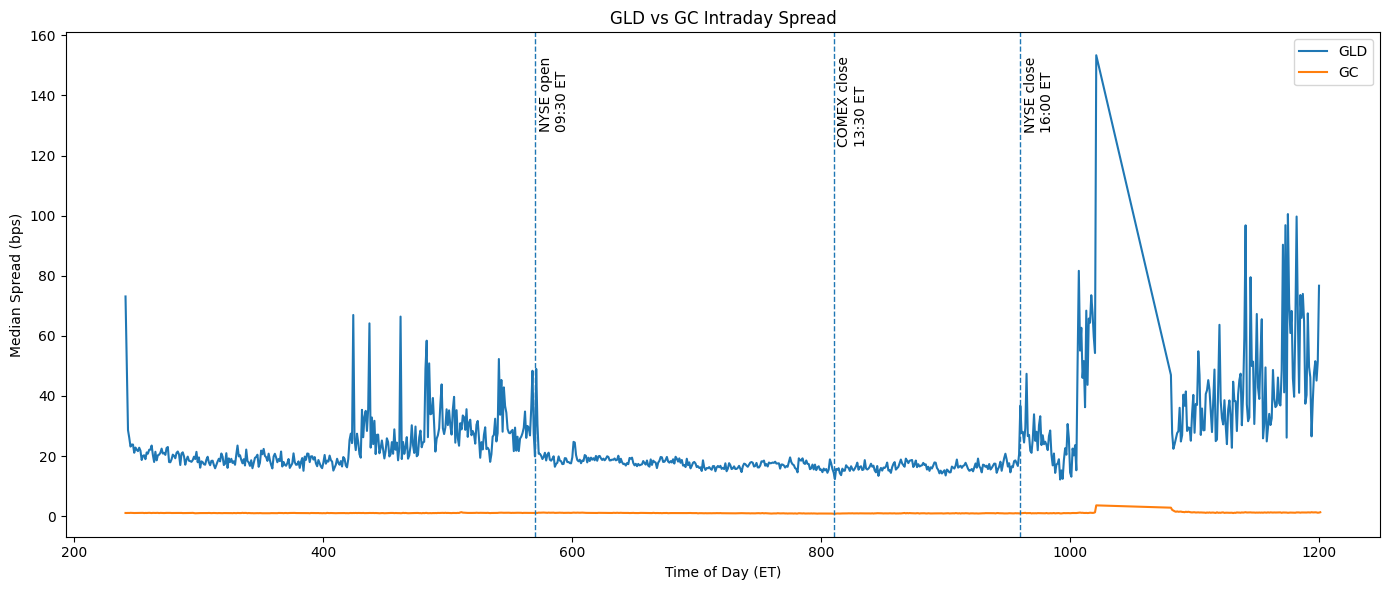

In [77]:
plt.figure(figsize=(14, 6))

plt.plot(
    spread_comparison['minute_num'],
    spread_comparison['gld_spread_bps'],
    label='GLD'
)

plt.plot(
    spread_comparison['minute_num'],
    spread_comparison['gc_spread_bps'],
    label='GC'
)

# Session markers
session_lines = {
    'NYSE open\n09:30 ET': 9 * 60 + 30,
    'COMEX close\n13:30 ET': 13 * 60 + 30,
    'NYSE close\n16:00 ET': 16 * 60
}

for label, x in session_lines.items():
    plt.axvline(
        x,
        linestyle='--',
        linewidth=1
    )

    plt.text(
        x + 3,
        plt.ylim()[1] * 0.95,
        label,
        rotation=90,
        va='top',
        ha='left'
    )

plt.xlabel('Time of Day (ET)')
plt.ylabel('Median Spread (bps)')
plt.title('GLD vs GC Intraday Spread')

# Legend now only needs GLD and GC
plt.legend()

plt.tight_layout()
plt.show()

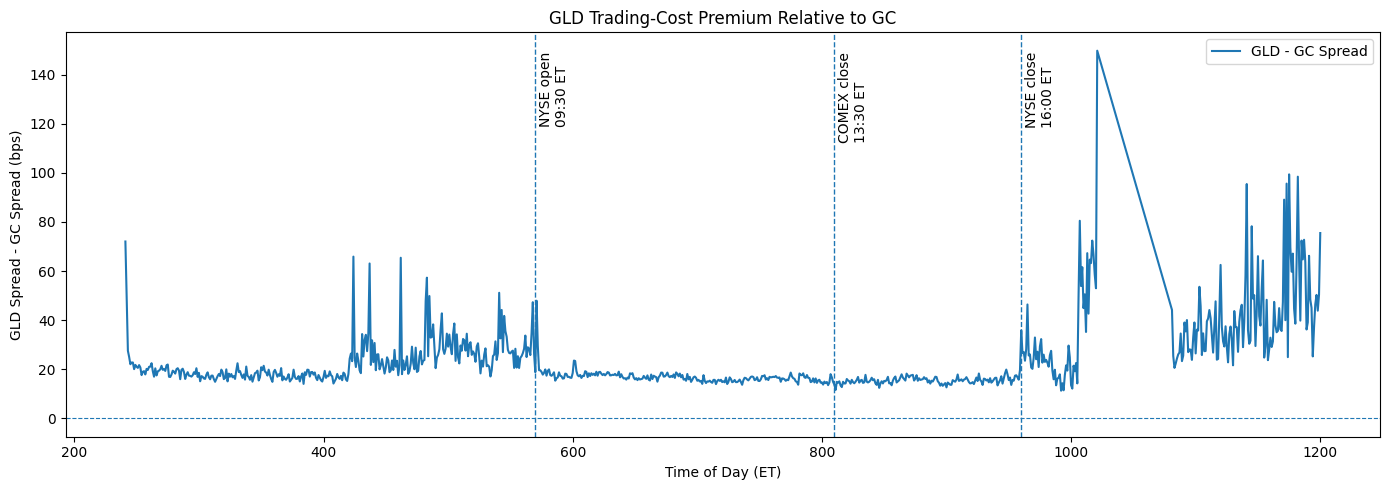

In [78]:
plt.figure(figsize=(14, 5))

plt.plot(
    spread_comparison['minute_num'],
    spread_comparison['spread_gap_bps'],
    label='GLD - GC Spread'
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=0.8
)

for label, x in session_lines.items():
    plt.axvline(
        x,
        linestyle='--',
        linewidth=1
    )

    plt.text(
        x + 3,
        plt.ylim()[1] * 0.95,
        label,
        rotation=90,
        va='top',
        ha='left'
    )

plt.xlabel('Time of Day (ET)')
plt.ylabel('GLD Spread - GC Spread (bps)')
plt.title('GLD Trading-Cost Premium Relative to GC')

plt.legend()
plt.tight_layout()
plt.show()

In [79]:
gc_spread.head(10)

,Time,symbol,last_ask,last_bid,avg_spread,mid_price,spread_proxy,proxy_spread_bps,minute_num,last_quote_spread,spread_bps
0,2026-07-08 00:01:00,GC\Z26,4195.4,4194.9,0.483393,4195.15,0.5,1.191852,1,0.5,1.152265
1,2026-07-08 00:01:00,GC\Q26,4134.7,4134.3,0.383499,4134.50,0.4,0.967469,1,0.4,0.927557
2,2026-07-08 00:02:00,GC\Q26,4133.8,4133.4,0.403323,4133.60,0.4,0.967680,2,0.4,0.975718
3,2026-07-08 00:02:00,GC\U26,4147.9,4147.3,0.589615,4147.60,0.6,1.446620,2,0.6,1.421581
4,2026-07-08 00:03:00,GC\Q26,4133.2,4132.8,0.402329,4133.00,0.4,0.967820,3,0.4,0.973456
5,2026-07-08 00:04:00,GC\Z26,4195.1,4194.6,0.480162,4194.85,0.5,1.191938,4,0.5,1.144646
6,2026-07-08 00:04:00,GC\Q26,4134.4,4134.0,0.383195,4134.20,0.4,0.967539,4,0.4,0.926890
7,2026-07-08 00:05:00,GC\Q26,4133.9,4133.4,0.441049,4133.65,0.5,1.209585,5,0.5,1.066973
8,2026-07-08 00:06:00,GC\Q26,4134.2,4133.7,0.452083,4133.95,0.5,1.209497,6,0.5,1.093587
9,2026-07-08 00:07:00,GC\Q26,4135.4,4134.9,0.418833,4135.15,0.5,1.209146,7,0.5,1.012860


In [80]:
gld_spread.head(10)

,Time,symbol,last_ask,last_bid,avg_spread,mid_price,spread_bps,minute_num,last_quote_spread,actual_spread_bps,proxy_spread_bps
0,2026-07-08 04:01:00,GLD,378.08,377.86,0.998053,377.970,26.405619,241,0.22,26.405619,5.820568
1,2026-07-08 04:02:00,GLD,377.91,377.75,2.016992,377.830,53.383589,242,0.16,53.383589,4.234709
2,2026-07-08 04:03:00,GLD,377.96,377.80,0.913224,377.880,24.167049,243,0.16,24.167049,4.234148
3,2026-07-08 04:04:00,GLD,377.89,377.77,0.859441,377.830,22.746752,244,0.12,22.746752,3.176032
4,2026-07-08 04:05:00,GLD,377.81,377.69,0.844301,377.750,22.350782,245,0.12,22.350782,3.176704
5,2026-07-08 04:06:00,GLD,378.02,377.91,0.786912,377.965,20.819715,246,0.11,20.819715,2.910322
6,2026-07-08 04:07:00,GLD,377.93,377.89,0.865933,377.910,22.913730,247,0.04,22.913730,1.058453
7,2026-07-08 04:08:00,GLD,377.99,377.87,0.911018,377.930,24.105456,248,0.12,24.105456,3.175191
8,2026-07-08 04:09:00,GLD,378.05,377.95,0.462391,378.000,12.232564,249,0.10,12.232564,2.645503
9,2026-07-08 04:10:00,GLD,378.06,NaN,0.827845,NaN,NaN,250,NaN,NaN,NaN


### 3 - Lead-Lag

*Q: Lead-lag - 1-minute returns: does GC lead GLD around NYSE open vs around macro prints? Simple lagged correlation is enough.*